# API con PokéAPI paso a paso 

## Objetivo
Entender cómo consumir una API externa, explorar su JSON, transformar los datos y prepararlos para análisis con `pandas`.

## Tecnologías
- Python
- requests
- pandas
- FastAPI
- PokéAPI

## Qué aprenderás
- Cómo hacer una petición HTTP a una API
- Cómo leer y explorar una respuesta JSON
- Cómo extraer campos útiles
- Cómo convertir los datos en un DataFrame
- Cómo hacer un pequeño análisis y visualización



## 1. Importaciones

En este bloque importamos las librerías necesarias:
- `requests` para conectarnos a la API
- `pandas` para trabajar con tablas de datos
- `FastAPI` para entender el contexto de la aplicación


In [1]:
from fastapi import FastAPI
import requests
import pandas as pd

## 2. Crear la aplicación

Aquí creamos el objeto principal de FastAPI.  
En este notebook no vamos a levantar el servidor, pero este objeto es el que se usaría en la aplicación real.


In [2]:
app = FastAPI()


## 3. URL base de PokéAPI

Guardamos la URL base para no repetirla en cada petición.


In [3]:
BASE_URL = "https://pokeapi.co/api/v2/pokemon"


## 4. Primera llamada a la API

Vamos a pedir solo 5 Pokémon para empezar.  
Esto hace el notebook más rápido y más fácil de explicar.


In [4]:
LIMIT = 5
response = requests.get(f"{BASE_URL}?limit={LIMIT}")

print("Status code:", response.status_code)
data = response.json()


Status code: 200


## 5. Explorar la estructura del JSON

Primero vemos qué claves principales trae la respuesta.


In [5]:
data.keys()

dict_keys(['count', 'next', 'previous', 'results'])

## 6. Ver la lista de resultados

La clave `results` contiene la lista de Pokémon devueltos por la API.


In [7]:
data["results"]

[{'name': 'bulbasaur', 'url': 'https://pokeapi.co/api/v2/pokemon/1/'},
 {'name': 'ivysaur', 'url': 'https://pokeapi.co/api/v2/pokemon/2/'},
 {'name': 'venusaur', 'url': 'https://pokeapi.co/api/v2/pokemon/3/'},
 {'name': 'charmander', 'url': 'https://pokeapi.co/api/v2/pokemon/4/'},
 {'name': 'charmeleon', 'url': 'https://pokeapi.co/api/v2/pokemon/5/'}]

## 7. Inspeccionar un solo Pokémon de la lista

Antes de recorrer todos, miramos un elemento para entender su estructura.


In [8]:
pokemon = data["results"][4]
print(pokemon)

{'name': 'charmeleon', 'url': 'https://pokeapi.co/api/v2/pokemon/5/'}


## 8. Obtener el detalle de un Pokémon

Cada elemento de `results` trae una `url`.  
Con esa URL hacemos otra petición para obtener el detalle completo.


In [9]:
poke_response = requests.get(pokemon["url"])
print("Status code detalle:", poke_response.status_code)

poke_data = poke_response.json()
poke_data.keys()

Status code detalle: 200


dict_keys(['abilities', 'base_experience', 'cries', 'forms', 'game_indices', 'height', 'held_items', 'id', 'is_default', 'location_area_encounters', 'moves', 'name', 'order', 'past_abilities', 'past_stats', 'past_types', 'species', 'sprites', 'stats', 'types', 'weight'])

## 9. Extraer solo los campos que nos interesan

Aquí nos quedamos con:
- `name`
- `height`
- `weight`
- `base_experience`


In [10]:
pokemon_clean = {
    "name": poke_data["name"],
    "height": poke_data["height"],
    "weight": poke_data["weight"],
    "base_experience": poke_data["base_experience"]
}

pokemon_clean

{'name': 'charmeleon', 'height': 11, 'weight': 190, 'base_experience': 142}

## 10. Repetir el proceso para varios Pokémon

Ahora recorremos los resultados y construimos una lista de diccionarios limpios.


In [11]:
results = []

for pokemon in data["results"]:
    poke_response = requests.get(pokemon["url"])

    if poke_response.status_code == 200:
        poke_data = poke_response.json()
        results.append({
            "name": poke_data["name"],
            "height": poke_data["height"],
            "weight": poke_data["weight"],
            "base_experience": poke_data["base_experience"]
        })
    else:
        print(f"Error al obtener datos de {pokemon['name']}")

results

[{'name': 'bulbasaur', 'height': 7, 'weight': 69, 'base_experience': 64},
 {'name': 'ivysaur', 'height': 10, 'weight': 130, 'base_experience': 142},
 {'name': 'venusaur', 'height': 20, 'weight': 1000, 'base_experience': 236},
 {'name': 'charmander', 'height': 6, 'weight': 85, 'base_experience': 62},
 {'name': 'charmeleon', 'height': 11, 'weight': 190, 'base_experience': 142}]

## 11. Convertir a DataFrame

Transformamos la lista de diccionarios en una tabla.


In [12]:
df = pd.DataFrame(results)
df

,name,height,weight,base_experience
0,bulbasaur,7,69,64
1,ivysaur,10,130,142
2,venusaur,20,1000,236
3,charmander,6,85,62
4,charmeleon,11,190,142


## 12. Ordenar por experiencia base

Aquí vemos los Pokémon con más `base_experience`.


In [13]:
df.sort_values("base_experience", ascending=False)

,name,height,weight,base_experience
2,venusaur,20,1000,236
4,charmeleon,11,190,142
1,ivysaur,10,130,142
0,bulbasaur,7,69,64
3,charmander,6,85,62


## 13. Visualización simple

Hacemos un gráfico sencillo para comparar la experiencia base por Pokémon.


Text(0, 0.5, 'Base experience')

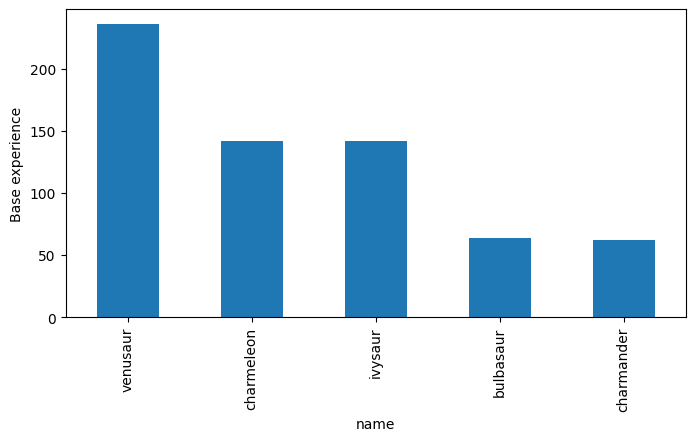

In [14]:
df_sorted = df.sort_values("base_experience", ascending=False)
ax = df_sorted.plot(x="name", y="base_experience", kind="bar", legend=False, figsize=(8,4))
ax.set_ylabel("Base experience")

## 17. Conclusiones

- Hemos consumido una API externa.
- Hemos explorado la estructura JSON.
- Hemos transformado datos en un DataFrame.
- Hemos hecho un pequeño análisis.

